   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


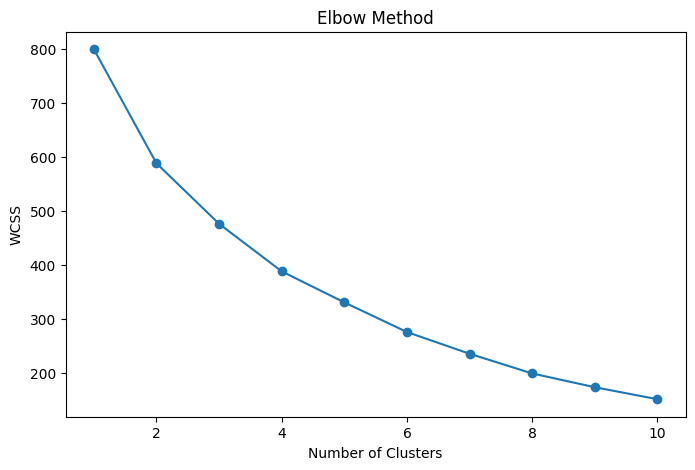

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  
0        3  
1        3  
2        3  
3        3  
4        3  


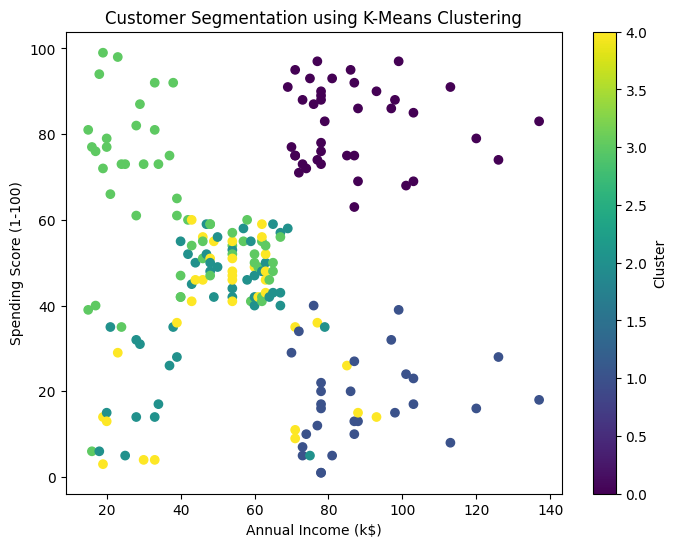


Customers in each cluster:
Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64


In [4]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# Load Dataset
df = pd.read_csv('/content/Mall_Customers_ml_two.csv')

# Display first rows
print(df.head())

# Convert Gender to Numerical Values
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Select Features
X = df[['Age', 'Gender', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

# Apply K-Means (change 5 if elbow suggests another value)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Display Results
print(df.head())

# Visualize Clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation using K-Means Clustering')
plt.colorbar(label='Cluster')
plt.show()

# Number of customers in each cluster
print("\nCustomers in each cluster:")
print(df['Cluster'].value_counts())